# Práctica 3 — GPC con enfoque intuitivo e industrial

**Objetivo:** comprender qué hace un GPC sin convertir la práctica en un ejercicio de manipulación polinómica.

Flujo de trabajo:

**datos → modelo → predicción → optimización → primera acción → repetir**

En lugar de partir directamente de los polinomios $A$ y $B$, generaremos datos de una planta que trataremos como **desconocida**, identificaremos un modelo sencillo y lo utilizaremos dentro del controlador.


## 1. Qué cambia respecto a MAC y DMC

MAC y DMC describen el proceso mediante colecciones de coeficientes obtenidos de respuestas experimentales. GPC utiliza un **modelo paramétrico compacto**.

Para esta práctica basta con interpretar:

- $A$: cómo influye el pasado de la salida.
- $B$: cómo influye el pasado de la entrada.
- $d$: retardo entrada–salida.
- $\Delta u$: cuánto cambiamos la acción de control.

La formulación CARIMA clásica y las ecuaciones diofánticas se comentarán en clase, pero **no las resolveremos a mano**.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

np.random.seed(7)


## 2. Generamos datos de una planta «desconocida»

El profesor conoce la planta usada para generar los datos; el controlador no. Esto reproduce mejor el flujo de trabajo industrial: medimos $u(k)$ e $y(k)$ y tratamos de obtener un modelo útil para predecir.


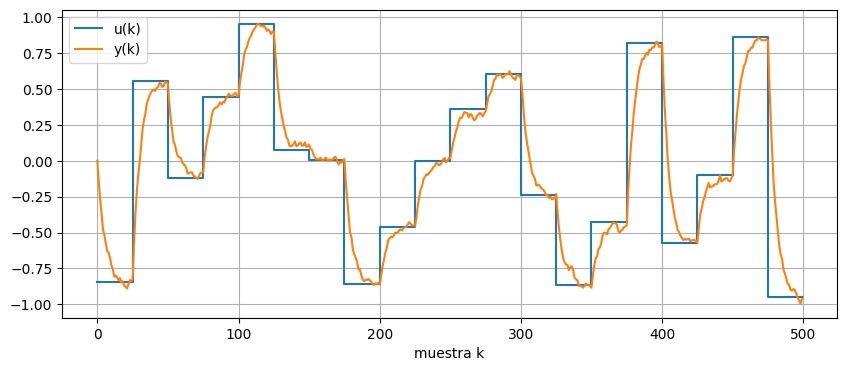

In [2]:
# Planta real SOLO para generar datos
# y(k) = a*y(k-1) + b*u(k-1) + perturbación
a_real = 0.82
b_real = 0.18
N = 500

# Entrada de identificación: cambios de nivel suficientemente ricos
u_id = np.zeros(N)
level = 0.0
for k in range(0, N, 25):
    level = np.random.uniform(-1.0, 1.0)
    u_id[k:k+25] = level

y_id = np.zeros(N)
for k in range(1, N):
    y_id[k] = a_real*y_id[k-1] + b_real*u_id[k-1] + 0.015*np.random.randn()

t = np.arange(N)
plt.figure(figsize=(10,4))
plt.step(t, u_id, where='post', label='u(k)')
plt.plot(t, y_id, label='y(k)')
plt.xlabel('muestra k'); plt.grid(True); plt.legend(); plt.show()


### Pregunta para clase

¿Sería buena idea identificar el modelo usando una entrada prácticamente constante?

<details>
<summary><b>Mostrar respuesta</b></summary>

No. Si la entrada apenas cambia, el proceso queda **poco excitado** y los datos contienen poca información sobre su dinámica.

En esas condiciones resulta difícil distinguir correctamente:

- cuánto de la salida se debe a la dinámica propia del proceso;
- cuánto se debe a la entrada;
- cuánto corresponde a ruido o perturbaciones.

Para identificar un modelo útil para predicción interesa que la señal de entrada recorra suficientemente la dinámica relevante del proceso, siempre dentro de límites seguros de operación.

</details>


## 3. Identificación sencilla del modelo

Usaremos un modelo ARX de primer orden:

\begin{align*}
y(k) = a\,y(k-1) + b\,u(k-1)
\end{align*}

Los parámetros se estiman por mínimos cuadrados. La intención no es estudiar identificación de sistemas en profundidad, sino hacer visible que **el modelo del GPC debe obtenerse de algún sitio**.


In [3]:
Phi = np.column_stack([y_id[:-1], u_id[:-1]])
Y = y_id[1:]
theta, *_ = np.linalg.lstsq(Phi, Y, rcond=None)
a_hat, b_hat = theta

print(f"a identificado = {a_hat:.4f}")
print(f"b identificado = {b_hat:.4f}")


a identificado = 0.8183
b identificado = 0.1825


## 4. ¿El modelo es suficientemente bueno?

Antes de diseñar el controlador, validamos. Un modelo puede ajustar bien unos datos y, aun así, predecir mal en otras condiciones.


RMSE de simulación = 0.0237


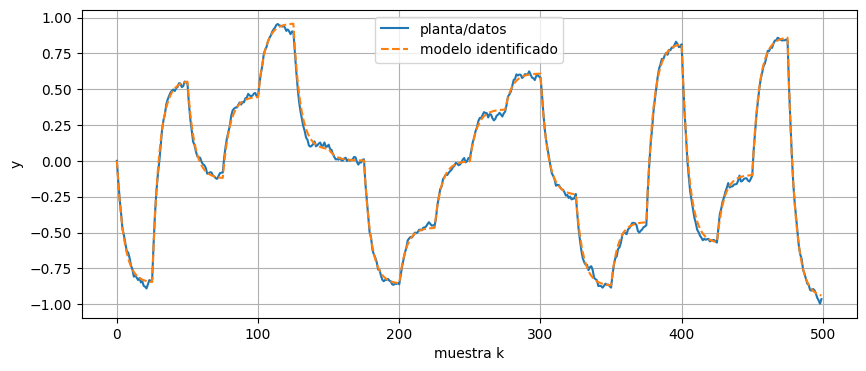

In [4]:
y_hat = np.zeros(N)
for k in range(1, N):
    y_hat[k] = a_hat*y_hat[k-1] + b_hat*u_id[k-1]

rmse = np.sqrt(np.mean((y_id-y_hat)**2))
print(f"RMSE de simulación = {rmse:.4f}")

plt.figure(figsize=(10,4))
plt.plot(y_id, label='planta/datos')
plt.plot(y_hat, '--', label='modelo identificado')
plt.xlabel('muestra k'); plt.ylabel('y')
plt.grid(True); plt.legend(); plt.show()


## 5. El predictor: la idea esencial de GPC

En cada instante imaginamos varias acciones futuras y usamos el modelo para responder:

> **Si aplico estos cambios de entrada, ¿cómo evolucionará la salida durante los próximos pasos?**

La implementación siguiente construye esa predicción directamente mediante simulación del modelo identificado. Así evitamos que la ecuación diofántica oculte la idea física.


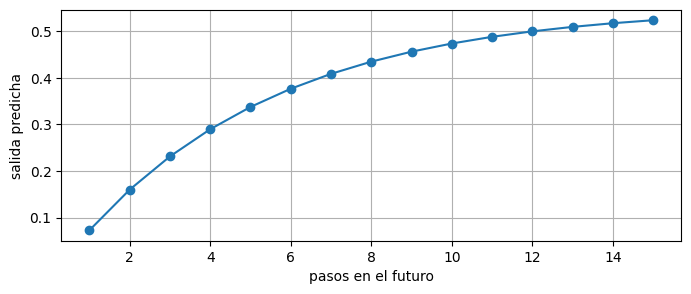

In [5]:
def predict_outputs(y0, u_prev, du_seq, a, b, Hp):
    """Predice Hp salidas suponiendo que, tras du_seq, Δu=0."""
    y = float(y0)
    u = float(u_prev)
    pred = []
    for j in range(Hp):
        if j < len(du_seq):
            u += du_seq[j]
        y = a*y + b*u
        pred.append(y)
    return np.asarray(pred)

# Ejemplo visual
Hp = 15
du_example = np.array([0.4, 0.15, 0.0])
yp = predict_outputs(0.0, 0.0, du_example, a_hat, b_hat, Hp)
plt.figure(figsize=(8,3))
plt.plot(np.arange(1,Hp+1), yp, 'o-')
plt.xlabel('pasos en el futuro'); plt.ylabel('salida predicha')
plt.grid(True); plt.show()


## 6. Qué optimiza el controlador

Solo necesitamos retener dos objetivos:

1. que la salida predicha se acerque a la referencia;
2. que los cambios de entrada no sean innecesariamente bruscos.

De forma compacta:

\begin{align*}
J = \text{error futuro} + \lambda\,\text{esfuerzo de control}
\end{align*}

$\lambda$ actúa como un mando de **agresividad**: pequeño → seguimiento rápido; grande → movimientos más suaves.


In [6]:
def prediction_matrix(y, u_prev, a, b, Hp, Hu):
    f = predict_outputs(y, u_prev, np.zeros(Hu), a, b, Hp)
    G = np.zeros((Hp, Hu))
    for j in range(Hu):
        du = np.zeros(Hu)
        du[j] = 1.0
        G[:, j] = predict_outputs(y, u_prev, du, a, b, Hp) - f
    return f, G

def gpc_move(y, u_prev, ref_future, a, b, Hp=15, Hu=3, lam=1.0):
    f, G = prediction_matrix(y, u_prev, a, b, Hp, Hu)
    H = G.T @ G + lam*np.eye(Hu)
    rhs = G.T @ (ref_future - f)
    du_opt = np.linalg.solve(H, rhs)
    return du_opt[0], f, G


## 7. Simulación en horizonte deslizante

Calculamos una secuencia óptima, **aplicamos solo el primer incremento** y repetimos todo en la siguiente muestra.


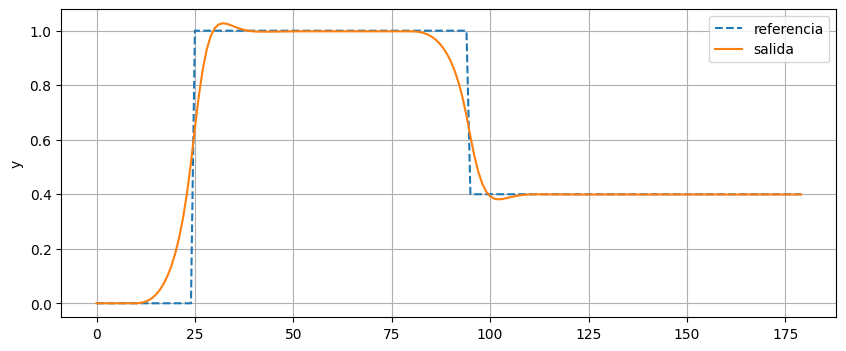

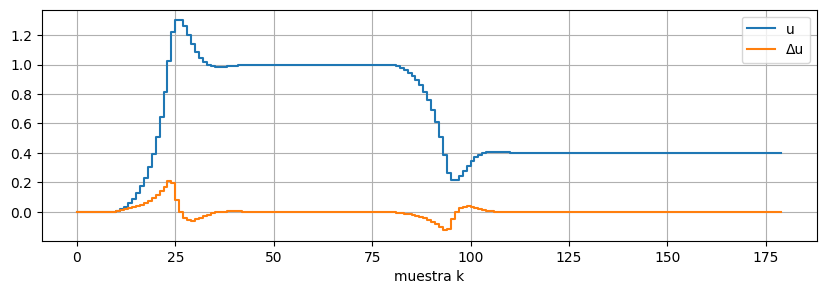

In [7]:
def simulate_gpc(a_model, b_model, lam=1.0, Hp=15, Hu=3,
                 a_plant=a_real, b_plant=b_real, disturbance=False):
    Nsim = 180
    r = np.zeros(Nsim + Hp + 1)
    r[25:95] = 1.0
    r[95:] = 0.4

    y = np.zeros(Nsim)
    u = np.zeros(Nsim)
    du = np.zeros(Nsim)

    for k in range(1, Nsim):
        ref_future = r[k+1:k+1+Hp]
        du[k], _, _ = gpc_move(y[k-1], u[k-1], ref_future,
                               a_model, b_model, Hp, Hu, lam)
        u[k] = u[k-1] + du[k]
        d = 0.12 if (disturbance and 110 <= k < 135) else 0.0
        y[k] = a_plant*y[k-1] + b_plant*u[k-1] + d

    return r[:Nsim], y, u, du

r,y,u,du = simulate_gpc(a_hat,b_hat,lam=1.0)

plt.figure(figsize=(10,4))
plt.plot(r, '--', label='referencia')
plt.plot(y, label='salida')
plt.grid(True); plt.legend(); plt.ylabel('y'); plt.show()

plt.figure(figsize=(10,3))
plt.step(np.arange(len(u)),u,where='post',label='u')
plt.step(np.arange(len(du)),du,where='post',label='Δu')
plt.grid(True); plt.legend(); plt.xlabel('muestra k'); plt.show()


## 8. Experimento 1 — efecto de $\lambda$

Ejecuta varios valores. Antes de mirar la gráfica, formula una predicción.

**Pregunta:** ¿qué esperas que ocurra al aumentar $\lambda$?

<details>
<summary><b>Mostrar respuesta</b></summary>

Al aumentar $\lambda$ damos más importancia a evitar cambios bruscos de la acción de control.

Por tanto, esperamos:

- menores valores de $\Delta u$;
- una acción de control más suave;
- generalmente, una respuesta más lenta;
- menor esfuerzo sobre el actuador.

Si $\lambda$ es demasiado pequeño, el controlador puede resultar excesivamente agresivo.

</details>


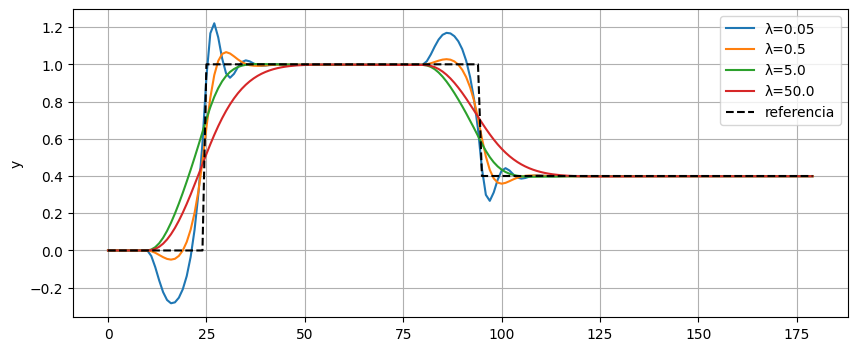

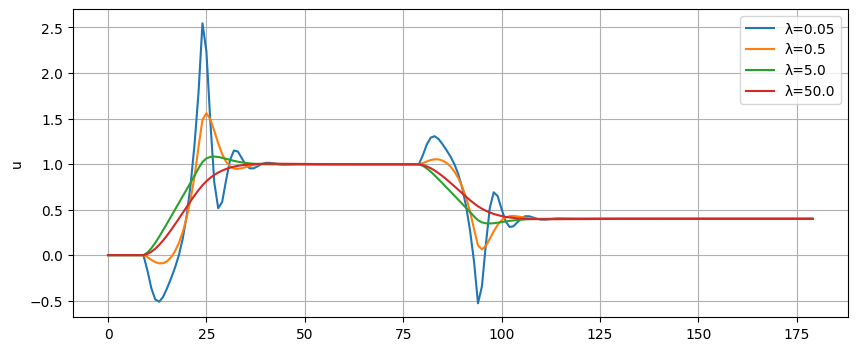

In [12]:
plt.figure(figsize=(10,4))
for lam in [0.05, 0.5, 5.0, 50.0]:
    r,y,u,du = simulate_gpc(a_hat,b_hat,lam=lam)
    plt.plot(y,label=f'λ={lam}')
plt.plot(r,'k--',label='referencia')
plt.grid(True); plt.legend(); plt.ylabel('y'); plt.show()

plt.figure(figsize=(10,4))
for lam in [0.05, 0.5, 5.0, 50.0]:
    r,y,u,du = simulate_gpc(a_hat,b_hat,lam=lam)
    plt.plot(u,label=f'λ={lam}')
#plt.plot(r,'k--',label='referencia')
plt.grid(True); plt.legend(); plt.ylabel('u'); plt.show()


<details>
<summary><b>Mostrar respuesta</b></summary>

Un $\lambda$ pequeño permite cambios de control mayores y suele acelerar el seguimiento. Un $\lambda$ grande penaliza esos movimientos y produce una respuesta más suave, normalmente más lenta.

La elección no consiste en «hacer el error mínimo a cualquier precio», sino en encontrar un compromiso compatible con los actuadores, el proceso y los objetivos de operación.

</details>


## 9. Experimento 2 — horizonte de predicción

Compara horizontes cortos y largos. Un horizonte largo permite «ver» más futuro, pero no convierte un modelo incorrecto en uno bueno.


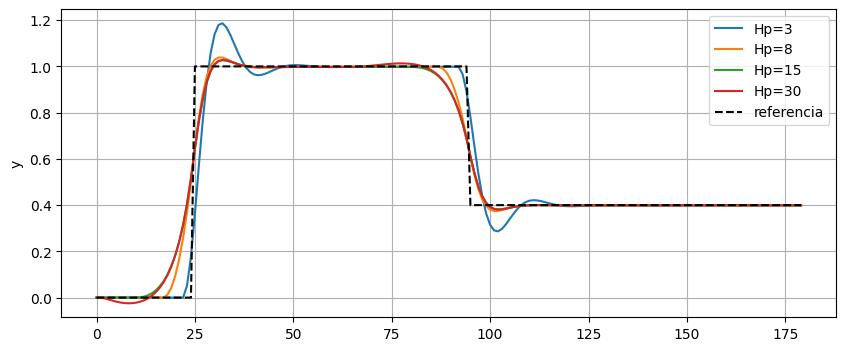

In [9]:
plt.figure(figsize=(10,4))
for Hp in [3, 8, 15, 30]:
    r,y,u,du = simulate_gpc(a_hat,b_hat,lam=1.0,Hp=Hp,Hu=min(3,Hp))
    plt.plot(y,label=f'Hp={Hp}')
plt.plot(r,'k--',label='referencia')
plt.grid(True); plt.legend(); plt.ylabel('y'); plt.show()


### Preguntas para clase

- ¿Existe ventaja en aumentar indefinidamente el horizonte?
- ¿Qué coste computacional tiene?
- ¿Qué sentido tiene predecir muy lejos si el modelo solo es fiable a corto plazo?

<details>
<summary><b>Mostrar respuesta</b></summary>

No existe una ventaja general en aumentar indefinidamente el horizonte.

Un horizonte mayor permite al controlador anticipar mejor dinámicas lentas, retardos o cambios futuros de referencia. Sin embargo:

- aumenta el tamaño del problema de predicción y optimización;
- incrementa el coste computacional;
- puede aportar muy poca mejora una vez que el horizonte cubre suficientemente la dinámica dominante;
- las predicciones lejanas suelen ser menos fiables por incertidumbre de modelo y perturbaciones.

Por tanto, el horizonte debe ser **suficientemente largo para capturar la dinámica relevante**, pero no arbitrariamente grande.

</details>


## 10. Experimento 3 — ¿qué pasa con un modelo malo?

Este experimento es central desde el punto de vista industrial. El optimizador puede resolver perfectamente su problema matemático y, aun así, tomar malas decisiones si las predicciones son incorrectas.


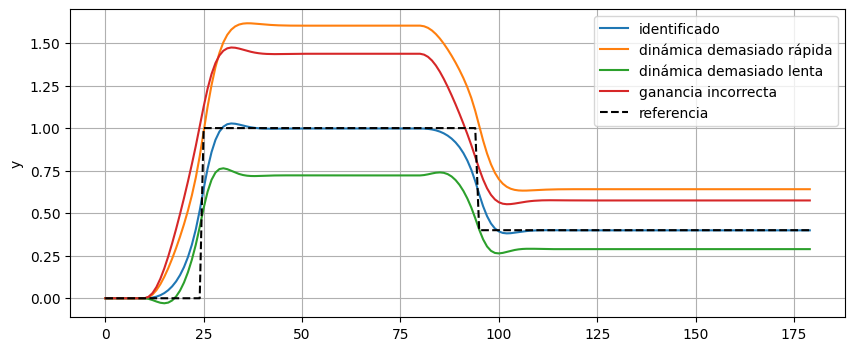

In [10]:
models = [
    (a_hat,b_hat,'identificado'),
    (0.65,b_hat,'dinámica demasiado rápida'),
    (0.93,b_hat,'dinámica demasiado lenta'),
    (a_hat,0.10,'ganancia incorrecta')
]
plt.figure(figsize=(10,4))
for am,bm,name in models:
    r,y,u,du = simulate_gpc(am,bm,lam=1.0)
    plt.plot(y,label=name)
plt.plot(r,'k--',label='referencia')
plt.grid(True); plt.legend(); plt.ylabel('y'); plt.show()


<details>
<summary><b>Mostrar respuesta</b></summary>

El optimizador no «arregla» automáticamente un mal modelo.

Puede resolver perfectamente el problema matemático que se le plantea, pero las decisiones serán tan buenas como las predicciones utilizadas. Por eso, **identificación y validación del modelo forman parte del diseño MPC**.

</details>


## 11. Experimento 4 — perturbación persistente

Introducimos una perturbación no medida durante un intervalo. Observa cómo aparece un error de predicción y cómo el lazo cerrado trata de compensarlo.

En la formulación CARIMA clásica, el tratamiento de perturbaciones persistentes es precisamente una de las razones para introducir la parte integrada del modelo.


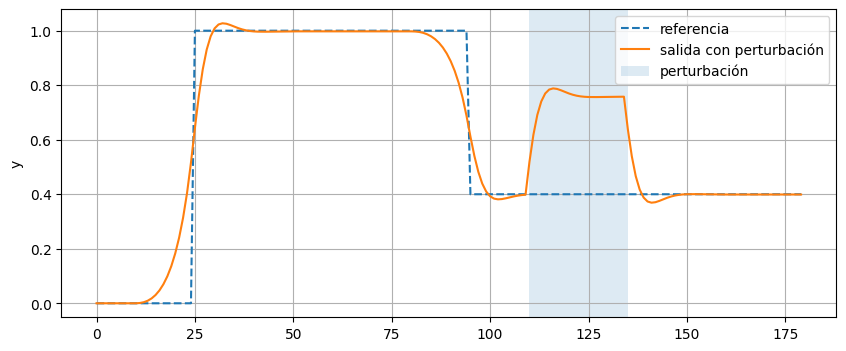

In [11]:
r,y,u,du = simulate_gpc(a_hat,b_hat,lam=1.0,disturbance=True)
plt.figure(figsize=(10,4))
plt.plot(r,'--',label='referencia')
plt.plot(y,label='salida con perturbación')
plt.axvspan(110,135,alpha=0.15,label='perturbación')
plt.grid(True); plt.legend(); plt.ylabel('y'); plt.show()


## 12. ¿Dónde queda CARIMA?

La formulación clásica escribe el proceso mediante polinomios y añade explícitamente un modelo de perturbación. Conceptualmente:

- dinámica del proceso;
- efecto de la entrada y posible tiempo muerto;
- perturbación/error de predicción;
- formulación incremental.

Las **ecuaciones diofánticas** son el procedimiento algebraico clásico que permite construir los predictores $j$ pasos por delante. En esta práctica hemos obtenido el mismo objeto que nos interesa —una relación entre acciones futuras y salidas futuras— mediante simulación recursiva del modelo.

> Para esta primera sesión interesa saber **qué construye** la ecuación diofántica y **para qué sirve**, no practicar su resolución manual.


## 13. Extensión: restricciones

Hasta aquí hemos resuelto un GPC sin restricciones. En una planta real aparecen límites como:

- apertura mínima/máxima de válvula;
- velocidad máxima de movimiento;
- presión, temperatura o nivel que no deben superarse.

Cuando añadimos estas restricciones, la solución analítica deja paso normalmente a un problema de optimización cuadrática. Este será el puente hacia formulaciones MPC más generales.


## 14. Discusión final MAC–DMC–GPC

| Aspecto | MAC | DMC | GPC |
|---|---|---|---|
| Modelo básico | Respuesta impulso | Respuesta escalón | Modelo paramétrico |
| Variable típica optimizada | $u$ | $\Delta u$ | $\Delta u$ |
| Identificación intuitiva | Ensayo impulso | Ensayo escalón | Datos entrada–salida |
| Memoria del modelo | Muchos coeficientes FIR | Coeficientes escalón | Orden de $A$, $B$ y retardo |
| Idea MPC | La misma | La misma | La misma |

### Preguntas de cierre

1. Si no puedo realizar un gran escalón en una planta en producción, ¿qué alternativa de modelado puede ser más natural?
2. ¿Qué parámetro modificarías para suavizar el actuador?
3. ¿Un horizonte mayor compensa un modelo pobre?
4. ¿Qué cambia conceptualmente cuando añadimos restricciones?

<details>
<summary><b>Mostrar respuestas</b></summary>

**1. Si no puedo realizar un gran escalón en una planta en producción, ¿qué alternativa de modelado puede ser más natural?**

Una alternativa natural es identificar un **modelo paramétrico** a partir de datos históricos o de pequeñas variaciones de operación suficientemente informativas. Esto encaja bien con la filosofía de GPC, siempre que los datos exciten adecuadamente la dinámica que queremos identificar.

---

**2. ¿Qué parámetro modificarías para suavizar el actuador?**

Aumentaría $\lambda$, es decir, la penalización aplicada a los cambios de control $\Delta u$.

Al aumentar $\lambda$:

- disminuye la agresividad del controlador;
- los cambios de entrada son más suaves;
- normalmente el seguimiento se vuelve más lento.

---

**3. ¿Un horizonte mayor compensa un modelo pobre?**

No.

El optimizador toma decisiones utilizando las predicciones del modelo. Si el modelo es incorrecto, aumentar el horizonte puede significar simplemente realizar **más predicciones incorrectas hacia el futuro**. La calidad del modelo sigue siendo fundamental.

---

**4. ¿Qué cambia conceptualmente cuando añadimos restricciones?**

La filosofía MPC no cambia: seguimos prediciendo, optimizando, aplicando la primera acción y repitiendo.

Lo que cambia es el problema de optimización. En el caso sin restricciones puede obtenerse una solución analítica sencilla. Al introducir límites sobre $u$, $\Delta u$ o $y$, normalmente debemos resolver en cada instante un problema de optimización, típicamente un **problema cuadrático (QP)** en el caso lineal.

</details>
